# EuRoC End-to-End Preprocessing and Split Pipeline

This notebook preprocesses raw EuRoC sequences from folders like `MH_01_easy/mav0`, creates per-sequence NumPy training windows, generates dataset splits, and saves reusable artifacts.

## Paper Upgrade Roadmap

Yes, this can be turned into a paper-grade project, but not as a single one-shot notebook edit. The scope in the prompt is a full research pipeline, not a small notebook patch.

What can be implemented directly in this notebook first:
- Better EuRoC evaluation: ATE, RPE, subsequence metrics, seed sweeps
- Stronger internal baselines: image-only, IMU-only, concat, attention ablations
- Synthetic low-texture experiments: blur, masking, frame drop, sync offsets, IMU noise
- Quantitative attention analysis and better figures
- LaTeX result table generation

What should move out of this notebook into modules or scripts:
- TUM-VI and KITTI dataset loaders
- EKF / stochastic cloning filter
- ORB-SLAM3, OpenVINS, TLIO baseline integration
- Reproducible multi-dataset training and evaluation scripts

Recommended execution order:
1. Strengthen EuRoC evaluation and ablations in this notebook.
2. Add synthetic robustness experiments and paper figures.
3. Refactor dataset/model/evaluation code into a package.
4. Add TUM-VI and KITTI.
5. Add EKF integration.
6. Add external baselines and final comparison tables.

Acceptance-level reality check:
- EuRoC-only is enough for a strong prototype, not enough for a top-tier main conference paper.
- The biggest research lift is EKF integration plus multi-dataset validation.
- The biggest engineering lift is external baselines and reproducible packaging.

## 1. Install and Import Dependencies

In [2]:
# Uncomment and run if packages are missing.
# %pip install pandas numpy matplotlib seaborn scikit-learn

from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_theme(style="whitegrid")

## 2. Configure Paths and Runtime Settings

In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Paths (Kaggle)
PROJECT_ROOT = Path("/kaggle/working")
RAW_DATA_ROOT = Path("/kaggle/input/datasets/bhavaniprasadm3/euroc-mav")

# Fallback for Kaggle mounted dataset folder name in the right pane
if not RAW_DATA_ROOT.exists():
    RAW_DATA_ROOT = Path("/kaggle/input/euroc_mav")

PROCESSED_ROOT = PROJECT_ROOT / "processed_data"
SEQUENCE_OUTPUT_DIR = PROCESSED_ROOT / "sequences"
SPLIT_DIR = PROCESSED_ROOT / "splits"
MODEL_DIR = PROCESSED_ROOT / "models"

for p in [PROCESSED_ROOT, SEQUENCE_OUTPUT_DIR, SPLIT_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Window settings
WINDOW_SIZE = 200      # IMU samples
STRIDE = 20            # sliding step
HORIZON = 200          # prediction horizon in samples

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Project root:", PROJECT_ROOT)
print("Raw data root:", RAW_DATA_ROOT)
print("Raw data exists:", RAW_DATA_ROOT.exists())
print("Processed output:", PROCESSED_ROOT)

Project root: /kaggle/working
Raw data root: /kaggle/input/datasets/bhavaniprasadm3/euroc-mav
Raw data exists: True
Processed output: /kaggle/working/processed_data


## 3. Load Input Data

In [4]:
def discover_sequences(root: Path):
    seqs = []
    for p in root.iterdir():
        if p.is_dir() and (p / "mav0").exists():
            seqs.append(p)
    return sorted(seqs)


def load_imu_csv(mav0_dir: Path) -> pd.DataFrame:
    imu_path = mav0_dir / "imu0" / "data.csv"
    imu = pd.read_csv(
        imu_path,
        comment="#",
        header=None,
        names=["timestamp_ns", "gyro_x", "gyro_y", "gyro_z", "acc_x", "acc_y", "acc_z"],
    )
    return imu.sort_values("timestamp_ns").reset_index(drop=True)


def load_gt_csv(mav0_dir: Path) -> pd.DataFrame:
    gt_path = mav0_dir / "state_groundtruth_estimate0" / "data.csv"
    gt = pd.read_csv(
        gt_path,
        comment="#",
        header=None,
        names=[
            "timestamp_ns", "p_x", "p_y", "p_z", "q_w", "q_x", "q_y", "q_z",
            "v_x", "v_y", "v_z", "bw_x", "bw_y", "bw_z", "ba_x", "ba_y", "ba_z",
        ],
    )
    return gt.sort_values("timestamp_ns").reset_index(drop=True)


sequence_paths = discover_sequences(RAW_DATA_ROOT)
print(f"Discovered {len(sequence_paths)} sequence folder(s)")
print([p.name for p in sequence_paths][:10])

sample_seq = sequence_paths[0]
sample_mav0 = sample_seq / "mav0"
imu_df = load_imu_csv(sample_mav0)
gt_df = load_gt_csv(sample_mav0)

print("Sample sequence:", sample_seq.name)
print("IMU rows:", len(imu_df), "GT rows:", len(gt_df))
imu_df.head()

Discovered 9 sequence folder(s)
['MH_01_easy', 'MH_02_easy', 'MH_03_medium', 'MH_04_difficult', 'MH_05_difficult', 'V1_03_difficult', 'V2_01_easy', 'V2_02_medium', 'V2_03_difficult']
Sample sequence: MH_01_easy
IMU rows: 36820 GT rows: 36382


,timestamp_ns,gyro_x,gyro_y,gyro_z,acc_x,acc_y,acc_z
0,1403636579758555392,-0.099135,0.147306,0.027227,8.147692,-0.375922,-2.402629
1,1403636579763555584,-0.099135,0.140324,0.029322,8.033281,-0.408610,-2.402629
2,1403636579768555520,-0.098437,0.127758,0.037699,7.886181,-0.424955,-2.435318
3,1403636579773555456,-0.102625,0.115890,0.045379,7.828976,-0.375922,-2.468007
4,1403636579778555392,-0.105418,0.108210,0.051662,7.714565,-0.408610,-2.557901


## 4. Clean and Validate Data

In [5]:
def clean_and_validate(imu: pd.DataFrame, gt: pd.DataFrame):
    imu = imu.drop_duplicates(subset=["timestamp_ns"]).dropna().copy()
    gt = gt.drop_duplicates(subset=["timestamp_ns"]).dropna().copy()

    imu["timestamp_ns"] = imu["timestamp_ns"].astype(np.int64)
    gt["timestamp_ns"] = gt["timestamp_ns"].astype(np.int64)

    assert imu["timestamp_ns"].is_monotonic_increasing, "IMU timestamps must be sorted"
    assert gt["timestamp_ns"].is_monotonic_increasing, "GT timestamps must be sorted"

    return imu.reset_index(drop=True), gt.reset_index(drop=True)


def interpolate_gt_to_imu(imu: pd.DataFrame, gt: pd.DataFrame) -> pd.DataFrame:
    imu_t = imu["timestamp_ns"].to_numpy(dtype=np.float64)
    gt_t = gt["timestamp_ns"].to_numpy(dtype=np.float64)

    gt_interp = pd.DataFrame({"timestamp_ns": imu_t.astype(np.int64)})
    for col in ["p_x", "p_y", "p_z", "v_x", "v_y", "v_z"]:
        gt_interp[col] = np.interp(imu_t, gt_t, gt[col].to_numpy(dtype=np.float64))

    return gt_interp

imu_df, gt_df = clean_and_validate(imu_df, gt_df)
gt_interp_df = interpolate_gt_to_imu(imu_df, gt_df)

print("Post-clean IMU rows:", len(imu_df), "Post-clean GT rows:", len(gt_df))
print("Interpolated GT rows:", len(gt_interp_df))
assert len(gt_interp_df) == len(imu_df)

Post-clean IMU rows: 36820 Post-clean GT rows: 36382
Interpolated GT rows: 36820


## 5. Perform Exploratory Data Analysis with Plots

,count,mean,std,min,25%,50%,75%,max
timestamp_ns,36820.0,1.403637e+18,5.314581e+10,1.403637e+18,1.403637e+18,1.403637e+18,1.403637e+18,1.403637e+18
gyro_x,36820.0,-2.331726e-03,1.663522e-01,-8.391543e-01,-5.166175e-02,-2.094395e-03,4.817109e-02,7.937757e-01
gyro_y,36820.0,2.172386e-02,1.401434e-01,-1.573589e+00,-3.979351e-02,2.094395e-02,8.028515e-02,4.035899e+00
gyro_z,36820.0,7.821335e-02,1.333984e-01,-8.873254e-01,2.303835e-02,8.028515e-02,1.403245e-01,1.588948e+00
acc_x,36820.0,9.120778e+00,1.314099e+00,-2.554632e+01,8.294791e+00,9.291801e+00,9.855683e+00,6.013111e+01
acc_y,36820.0,-7.566661e-02,5.965932e-01,-9.447073e+00,-4.821603e-01,-7.354987e-02,3.023717e-01,8.613508e+00
acc_z,36820.0,-3.364850e+00,1.105115e+00,-3.009824e+01,-3.873627e+00,-3.178989e+00,-2.598762e+00,4.609125e+00


/tmp/ipykernel_55/3921754052.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  imu_df[["acc_x", "acc_y", "acc_z"]].hist(ax=axes[0, 0], bins=40)
/tmp/ipykernel_55/3921754052.py:7: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  imu_df[["gyro_x", "gyro_y", "gyro_z"]].hist(ax=axes[0, 1], bins=40)


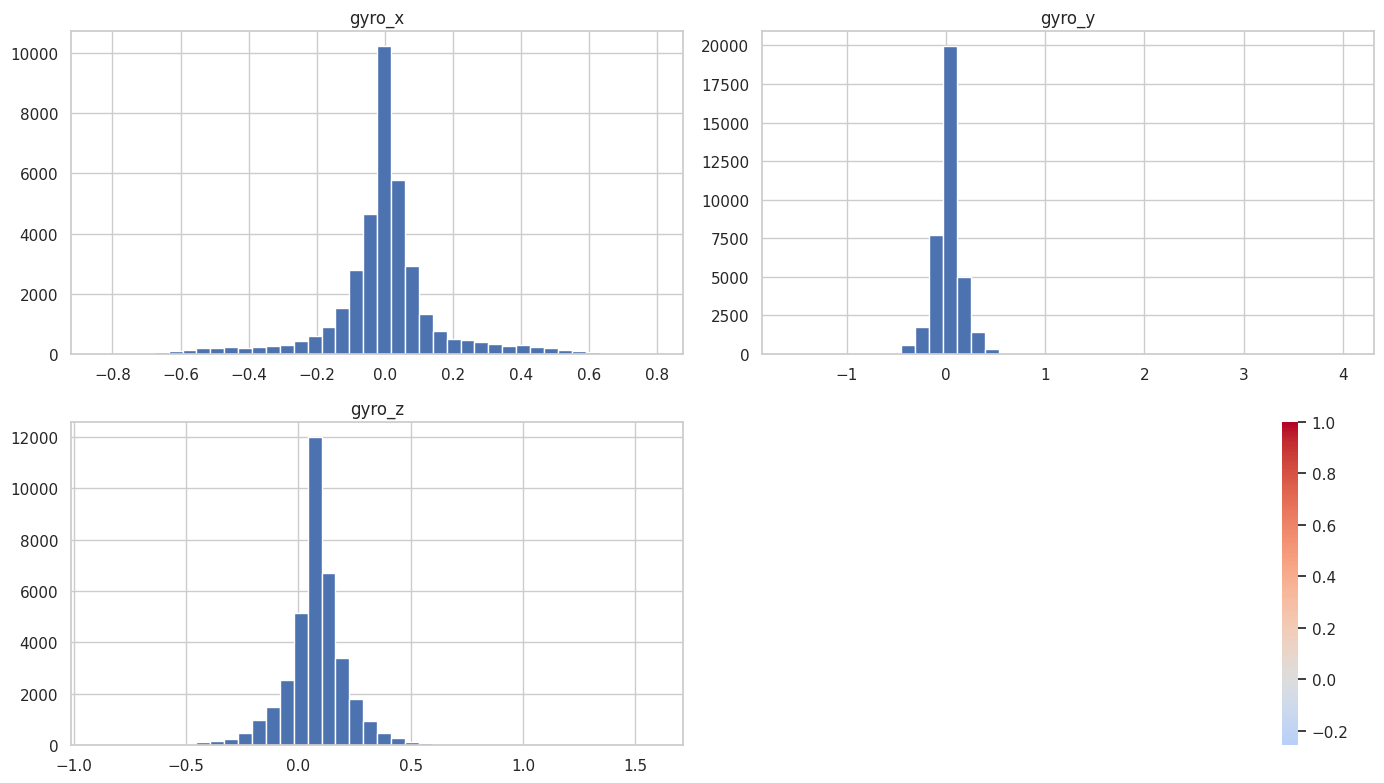

In [6]:
display(imu_df.describe().T)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
imu_df[["acc_x", "acc_y", "acc_z"]].hist(ax=axes[0, 0], bins=40)
axes[0, 0].set_title("Accel Histograms")

imu_df[["gyro_x", "gyro_y", "gyro_z"]].hist(ax=axes[0, 1], bins=40)
axes[0, 1].set_title("Gyro Histograms")

sns.boxplot(data=imu_df[["acc_x", "acc_y", "acc_z"]], ax=axes[1, 0])
axes[1, 0].set_title("Accel Boxplot")

corr = imu_df[["gyro_x", "gyro_y", "gyro_z", "acc_x", "acc_y", "acc_z"]].corr()
sns.heatmap(corr, ax=axes[1, 1], cmap="coolwarm", center=0, annot=False)
axes[1, 1].set_title("IMU Correlation")

plt.tight_layout()
plt.show()

## 6. Build Feature Transformations

In [7]:
def build_windows(imu: pd.DataFrame, gt_interp: pd.DataFrame, window_size=200, stride=20, horizon=200):
    imu_feat = imu[["gyro_x", "gyro_y", "gyro_z", "acc_x", "acc_y", "acc_z"]].to_numpy(dtype=np.float32)
    pos = gt_interp[["p_x", "p_y", "p_z"]].to_numpy(dtype=np.float32)

    X_list, y_list = [], []
    max_start = len(imu_feat) - window_size - horizon
    for start in range(0, max_start + 1, stride):
        end = start + window_size
        target_idx = end + horizon - 1
        X_list.append(imu_feat[start:end])
        y_list.append(pos[target_idx] - pos[end - 1])

    if not X_list:
        return np.empty((0, window_size, 6), dtype=np.float32), np.empty((0, 3), dtype=np.float32)

    return np.stack(X_list, axis=0), np.stack(y_list, axis=0)


def process_sequence(seq_path: Path):
    mav0 = seq_path / "mav0"
    gt_path = mav0 / "state_groundtruth_estimate0" / "data.csv"
    imu_path = mav0 / "imu0" / "data.csv"

    if not imu_path.exists() or not gt_path.exists():
        return {"sequence": seq_path.name, "status": "skipped_missing_files", "samples": 0}

    imu = load_imu_csv(mav0)
    gt = load_gt_csv(mav0)
    imu, gt = clean_and_validate(imu, gt)
    gt_interp = interpolate_gt_to_imu(imu, gt)
    X, y = build_windows(imu, gt_interp, WINDOW_SIZE, STRIDE, HORIZON)

    np.save(SEQUENCE_OUTPUT_DIR / f"{seq_path.name}_X.npy", X)
    np.save(SEQUENCE_OUTPUT_DIR / f"{seq_path.name}_y.npy", y)

    meta = {
        "sequence": seq_path.name,
        "status": "ok",
        "imu_rows": int(len(imu)),
        "gt_rows": int(len(gt)),
        "samples": int(len(X)),
        "window_size": int(WINDOW_SIZE),
        "stride": int(STRIDE),
        "horizon": int(HORIZON),
    }
    with open(SEQUENCE_OUTPUT_DIR / f"{seq_path.name}_meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)
    return meta


records = []
for seq_path in sequence_paths:
    rec = process_sequence(seq_path)
    records.append(rec)
    print(f"{rec['sequence']}: {rec['status']} ({rec['samples']} samples)")

manifest_df = pd.DataFrame(records).sort_values("sequence").reset_index(drop=True)
manifest_df.to_csv(SEQUENCE_OUTPUT_DIR / "manifest.csv", index=False)
manifest_df.head()

MH_01_easy: ok (1822 samples)
MH_02_easy: ok (1501 samples)
MH_03_medium: ok (1331 samples)
MH_04_difficult: ok (997 samples)
MH_05_difficult: ok (1117 samples)
V1_03_difficult: ok (1056 samples)
V2_01_easy: ok (1121 samples)
V2_02_medium: ok (1155 samples)
V2_03_difficult: ok (1149 samples)


,sequence,status,imu_rows,gt_rows,samples,window_size,stride,horizon
0,MH_01_easy,ok,36820,36382,1822,200,20,200
1,MH_02_easy,ok,30400,29993,1501,200,20,200
2,MH_03_medium,ok,27008,26302,1331,200,20,200
3,MH_04_difficult,ok,20320,19753,997,200,20,200
4,MH_05_difficult,ok,22721,22212,1117,200,20,200


## 7. Split Data for Training and Testing

In [8]:
ok_df = manifest_df[(manifest_df["status"] == "ok") & (manifest_df["samples"] > 0)].copy()
sequences = ok_df["sequence"].tolist()

if len(sequences) == 0:
    raise ValueError("No valid processed sequences found")


def load_split_arrays(split_sequences):
    if len(split_sequences) == 0:
        return (
            np.empty((0, WINDOW_SIZE, 6), dtype=np.float32),
            np.empty((0, 3), dtype=np.float32),
            np.empty((0,), dtype=object),
        )

    X_parts, y_parts, seq_col = [], [], []
    for seq in split_sequences:
        x = np.load(SEQUENCE_OUTPUT_DIR / f"{seq}_X.npy")
        y = np.load(SEQUENCE_OUTPUT_DIR / f"{seq}_y.npy")
        X_parts.append(x)
        y_parts.append(y)
        seq_col.extend([seq] * len(x))
    return np.concatenate(X_parts, axis=0), np.concatenate(y_parts, axis=0), np.array(seq_col)


if len(sequences) >= 3:
    split_mode = "sequence_level"
    train_seqs, test_seqs = train_test_split(sequences, test_size=0.2, random_state=SEED)
    train_seqs, val_seqs = train_test_split(train_seqs, test_size=0.2, random_state=SEED)

    X_train, y_train, seq_train = load_split_arrays(train_seqs)
    X_val, y_val, seq_val = load_split_arrays(val_seqs)
    X_test, y_test, seq_test = load_split_arrays(test_seqs)
else:
    split_mode = "sample_level_fallback"
    train_seqs, val_seqs, test_seqs = sequences, [], []

    X_all, y_all, seq_all = load_split_arrays(sequences)

    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X_all, y_all, test_size=0.3, random_state=SEED
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=SEED
    )
    seq_train = np.array(["sample_split"] * len(X_train))
    seq_val = np.array(["sample_split"] * len(X_val))
    seq_test = np.array(["sample_split"] * len(X_test))

for name, items in [("train", train_seqs), ("val", val_seqs), ("test", test_seqs)]:
    with open(SPLIT_DIR / f"{name}_sequences.txt", "w", encoding="utf-8") as f:
        if len(items) > 0:
            f.write("\n".join(items) + "\n")

print("Split mode:", split_mode)
print("Sequence split sizes:", len(train_seqs), len(val_seqs), len(test_seqs))
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Split mode: sequence_level
Sequence split sizes: 5 2 2
Train: (5715, 200, 6) (5715, 3)
Val: (2878, 200, 6) (2878, 3)
Test: (2656, 200, 6) (2656, 3)


## 8. Train Baseline Model

In [9]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

baseline_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0, random_state=SEED)),
    ]
)

baseline_model.fit(X_train_flat, y_train)
val_pred = baseline_model.predict(X_val_flat)
test_pred = baseline_model.predict(X_test_flat)

print("Baseline model trained.")
print("Validation predictions shape:", val_pred.shape)
print("Test predictions shape:", test_pred.shape)

Baseline model trained.
Validation predictions shape: (2878, 3)
Test predictions shape: (2656, 3)


## 9. Evaluate Model with Metrics

,split,mse,rmse,mae,r2
0,val,0.256414,0.506374,0.365528,-1.000370
1,test,0.231000,0.480625,0.335143,-0.523284


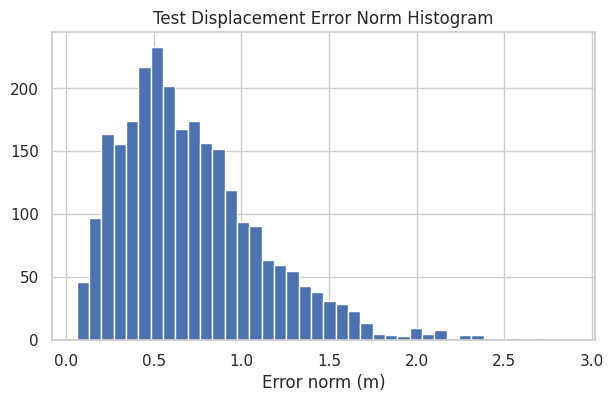

In [10]:
def regression_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"split": name, "mse": mse, "rmse": rmse, "mae": mae, "r2": r2}

metrics_rows = [
    regression_metrics(y_val, val_pred, "val"),
    regression_metrics(y_test, test_pred, "test"),
]
metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

err = y_test - test_pred
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.hist(np.linalg.norm(err, axis=1), bins=40)
ax.set_title("Test Displacement Error Norm Histogram")
ax.set_xlabel("Error norm (m)")
plt.show()

## 10. Tune Hyperparameters

In [11]:
param_grid = {"reg__alpha": [0.1, 1.0, 10.0]}
search = GridSearchCV(
    estimator=Pipeline([("scaler", StandardScaler()), ("reg", Ridge(random_state=SEED))]),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
)
search.fit(X_train_flat, y_train)

best_model = search.best_estimator_
best_val_pred = best_model.predict(X_val_flat)

print("Best params:", search.best_params_)
print("Best CV score (neg MSE):", search.best_score_)
print("Best model val RMSE:", np.sqrt(mean_squared_error(y_val, best_val_pred)))

Best params: {'reg__alpha': 10.0}
Best CV score (neg MSE): -0.37561845779418945
Best model val RMSE: 0.4880127435568054


## 11. Save Model and Outputs

In [12]:
best_test_pred = best_model.predict(X_test_flat)

metrics_final = pd.DataFrame([
    regression_metrics(y_train, best_model.predict(X_train_flat), "train"),
    regression_metrics(y_val, best_model.predict(X_val_flat), "val"),
    regression_metrics(y_test, best_test_pred, "test"),
])
metrics_final.to_csv(SPLIT_DIR / "metrics_summary.csv", index=False)

joblib.dump(best_model, MODEL_DIR / "ridge_displacement_model.joblib")

split_manifest = {
    "train_sequences": train_seqs,
    "val_sequences": val_seqs,
    "test_sequences": test_seqs,
    "split_mode": split_mode,
    "seed": SEED,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "horizon": HORIZON,
}
with open(SPLIT_DIR / "split_manifest.json", "w", encoding="utf-8") as f:
    json.dump(split_manifest, f, indent=2)

metrics_final

,split,mse,rmse,mae,r2
0,train,0.209722,0.457955,0.319293,0.325032
1,val,0.238156,0.488013,0.353636,-0.861639
2,test,0.218002,0.466907,0.325448,-0.437559


## 12. Run Automated Checks and Assertions

In [13]:
assert X_train.ndim == 3 and X_train.shape[2] == 6
assert y_train.ndim == 2 and y_train.shape[1] == 3
assert len(X_train) > 0 and len(X_val) > 0 and len(X_test) > 0

if len(val_seqs) > 0 and len(test_seqs) > 0:
    assert set(train_seqs).isdisjoint(val_seqs)
    assert set(train_seqs).isdisjoint(test_seqs)
    assert set(val_seqs).isdisjoint(test_seqs)

assert (SPLIT_DIR / "split_manifest.json").exists()
assert (SPLIT_DIR / "metrics_summary.csv").exists()
assert (MODEL_DIR / "ridge_displacement_model.joblib").exists()

print("All automated checks passed.")

# Final verification cell
example_seq = train_seqs[0]
example_X = np.load(SEQUENCE_OUTPUT_DIR / f"{example_seq}_X.npy")
example_y = np.load(SEQUENCE_OUTPUT_DIR / f"{example_seq}_y.npy")
print("Example sequence:", example_seq)
print("Example X shape:", example_X.shape)
print("Example y shape:", example_y.shape)
print("Split mode:", split_mode)
print("Split counts:", {"train": len(train_seqs), "val": len(val_seqs), "test": len(test_seqs)})

All automated checks passed.
Example sequence: MH_04_difficult
Example X shape: (997, 200, 6)
Example y shape: (997, 3)
Split mode: sequence_level
Split counts: {'train': 5, 'val': 2, 'test': 2}


In [14]:
# Optional: minimal cross-attention-ready model skeleton (PyTorch)
# This cell defines model classes only; train loop can be added after validating data volumes.

import torch
import torch.nn as nn


class TinyIMUEncoder(nn.Module):
    def __init__(self, in_dim=6, hid=128):
        super().__init__()
        self.rnn = nn.GRU(in_dim, hid, batch_first=True, bidirectional=True)
        self.proj = nn.Linear(hid * 2, hid)

    def forward(self, x):  # x: [B, T, 6]
        h, _ = self.rnn(x)
        return self.proj(h)  # [B, T, H]


class TinyImageEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(64, out_dim)

    def forward(self, img):  # [B, 1, H, W]
        z = self.net(img).flatten(1)
        return self.fc(z).unsqueeze(1)  # [B, 1, H]


class IMUGuidedCrossAttentionRegressor(nn.Module):
    def __init__(self, hid=128, n_heads=4):
        super().__init__()
        self.imu_enc = TinyIMUEncoder(in_dim=6, hid=hid)
        self.img_enc = TinyImageEncoder(out_dim=hid)
        self.cross_attn = nn.MultiheadAttention(embed_dim=hid, num_heads=n_heads, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, 3))

    def forward(self, x_imu, x_img):
        imu_tokens = self.imu_enc(x_imu)         # [B, T, H]
        img_token = self.img_enc(x_img)          # [B, 1, H]
        fused, _ = self.cross_attn(query=img_token, key=imu_tokens, value=imu_tokens)
        return self.head(fused.squeeze(1))       # [B, 3]


print("Defined IMU-guided cross-attention model skeleton.")
print("Next step: build DataLoader from processed_data/multimodal and train.")

Defined IMU-guided cross-attention model skeleton.
Next step: build DataLoader from processed_data/multimodal and train.


In [15]:
print("defined:", "make_multimodal_samples_for_sequence" in globals())

defined: False


In [17]:
# =====================================================
# COMPLETE Multimodal Data Generation (Self-Contained)
# Run this cell to generate image+IMU samples
# =====================================================

import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import json
from tqdm import tqdm

# Configuration
TARGET_IMG_SIZE = (160, 120)  # width, height
IMAGE_STEP = 10               # sample every Nth camera frame

# Helper functions (copied from your notebook)
def load_imu_csv(mav0_dir):
    imu_path = mav0_dir / "imu0" / "data.csv"
    imu = pd.read_csv(
        imu_path,
        comment="#",
        header=None,
        names=["timestamp_ns", "gyro_x", "gyro_y", "gyro_z", "acc_x", "acc_y", "acc_z"],
    )
    return imu.sort_values("timestamp_ns").reset_index(drop=True)

def load_gt_csv(mav0_dir):
    gt_path = mav0_dir / "state_groundtruth_estimate0" / "data.csv"
    gt = pd.read_csv(
        gt_path,
        comment="#",
        header=None,
        names=[
            "timestamp_ns", "p_x", "p_y", "p_z", "q_w", "q_x", "q_y", "q_z",
            "v_x", "v_y", "v_z", "bw_x", "bw_y", "bw_z", "ba_x", "ba_y", "ba_z",
        ],
    )
    return gt.sort_values("timestamp_ns").reset_index(drop=True)

def clean_and_validate(imu, gt):
    imu = imu.drop_duplicates(subset=["timestamp_ns"]).dropna().copy()
    gt = gt.drop_duplicates(subset=["timestamp_ns"]).dropna().copy()
    imu["timestamp_ns"] = imu["timestamp_ns"].astype(np.int64)
    gt["timestamp_ns"] = gt["timestamp_ns"].astype(np.int64)
    return imu.reset_index(drop=True), gt.reset_index(drop=True)

def interpolate_gt_to_imu(imu, gt):
    imu_t = imu["timestamp_ns"].to_numpy(dtype=np.float64)
    gt_t = gt["timestamp_ns"].to_numpy(dtype=np.float64)
    gt_interp = pd.DataFrame({"timestamp_ns": imu_t.astype(np.int64)})
    for col in ["p_x", "p_y", "p_z", "v_x", "v_y", "v_z"]:
        gt_interp[col] = np.interp(imu_t, gt_t, gt[col].to_numpy(dtype=np.float64))
    return gt_interp

def load_cam0_index(mav0_dir):
    cam_idx = pd.read_csv(
        mav0_dir / "cam0" / "data.csv",
        comment="#",
        header=None,
        names=["timestamp_ns", "filename"],
    )
    cam_idx["timestamp_ns"] = cam_idx["timestamp_ns"].astype(np.int64)
    return cam_idx.sort_values("timestamp_ns").reset_index(drop=True)

def nearest_index(sorted_ts, t_ns):
    pos = np.searchsorted(sorted_ts, t_ns)
    if pos <= 0:
        return 0
    if pos >= len(sorted_ts):
        return len(sorted_ts) - 1
    left, right = pos - 1, pos
    return left if abs(sorted_ts[left] - t_ns) <= abs(sorted_ts[right] - t_ns) else right

# Main function
def make_multimodal_samples_for_sequence(seq_path, max_images=None):
    """Create synchronized IMU + image samples for a sequence"""
    mav0 = seq_path / "mav0"
    imu = load_imu_csv(mav0)
    gt = load_gt_csv(mav0)
    imu, gt = clean_and_validate(imu, gt)
    gt_interp = interpolate_gt_to_imu(imu, gt)
    cam_idx = load_cam0_index(mav0)

    imu_ts = imu["timestamp_ns"].to_numpy(dtype=np.int64)
    imu_feat = imu[["gyro_x", "gyro_y", "gyro_z", "acc_x", "acc_y", "acc_z"]].to_numpy(dtype=np.float32)
    pos = gt_interp[["p_x", "p_y", "p_z"]].to_numpy(dtype=np.float32)

    rows = cam_idx.iloc[::IMAGE_STEP].reset_index(drop=True)
    if max_images is not None:
        rows = rows.iloc[:max_images]

    X_imu, X_img, y_disp, valid_ts = [], [], [], []

    for _, r in tqdm(rows.iterrows(), total=len(rows), desc=f"Processing {seq_path.name}"):
        t_cam = int(r["timestamp_ns"])
        i = nearest_index(imu_ts, t_cam)

        start = i - WINDOW_SIZE + 1
        end = i + 1
        target_idx = i + HORIZON

        if start < 0 or target_idx >= len(imu_feat):
            continue

        img_path = mav0 / "cam0" / "data" / str(r["filename"])
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, TARGET_IMG_SIZE, interpolation=cv2.INTER_AREA)
        img = (img.astype(np.float32) / 255.0)[None, :, :]  # [1, H, W]

        x_imu = imu_feat[start:end]  # [T, 6]
        disp = pos[target_idx] - pos[i]

        X_imu.append(x_imu)
        X_img.append(img)
        y_disp.append(disp)
        valid_ts.append(t_cam)

    if len(X_imu) == 0:
        return None

    return {
        "X_imu": np.stack(X_imu, axis=0).astype(np.float32),
        "X_img": np.stack(X_img, axis=0).astype(np.float32),
        "y": np.stack(y_disp, axis=0).astype(np.float32),
        "timestamp_ns": np.array(valid_ts, dtype=np.int64),
    }

# =====================================================
# Now run the actual processing
# =====================================================

print("=" * 60)
print("Generating Multimodal (IMU + Image) Dataset")
print("=" * 60)

MULTI_DIR = PROCESSED_ROOT / "multimodal"
MULTI_DIR.mkdir(parents=True, exist_ok=True)

multimodal_records = []

for seq_path in sequence_paths:
    out = make_multimodal_samples_for_sequence(seq_path, max_images=500)  # Reduced to 500 for speed
    if out is None:
        multimodal_records.append({"sequence": seq_path.name, "status": "no_samples", "samples": 0})
        print(f"{seq_path.name} -> no samples")
        continue

    # Save numpy arrays
    np.save(MULTI_DIR / f"{seq_path.name}_X_imu.npy", out["X_imu"])
    np.save(MULTI_DIR / f"{seq_path.name}_X_img.npy", out["X_img"])
    np.save(MULTI_DIR / f"{seq_path.name}_y.npy", out["y"])

    # Save metadata
    meta = {
        "sequence": seq_path.name,
        "status": "ok",
        "samples": int(out["X_imu"].shape[0]),
        "imu_shape": list(out["X_imu"].shape),
        "img_shape": list(out["X_img"].shape),
        "target_shape": list(out["y"].shape),
    }
    with open(MULTI_DIR / f"{seq_path.name}_meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    multimodal_records.append(meta)
    print(f"{seq_path.name} -> {out['X_imu'].shape} {out['X_img'].shape} {out['y'].shape}")

# Create manifest
multi_manifest = pd.DataFrame(multimodal_records)
multi_manifest.to_csv(MULTI_DIR / "manifest.csv", index=False)

print("\n" + "=" * 60)
print("Processing Complete!")
print(f"Saved to: {MULTI_DIR}")
print("=" * 60)
display(multi_manifest)

Generating Multimodal (IMU + Image) Dataset


Processing MH_01_easy: 100%|██████████| 369/369 [00:05<00:00, 66.84it/s]


MH_01_easy -> (365, 200, 6) (365, 1, 120, 160) (365, 3)


Processing MH_02_easy: 100%|██████████| 304/304 [00:04<00:00, 74.67it/s]


MH_02_easy -> (300, 200, 6) (300, 1, 120, 160) (300, 3)


...

Processing V2_02_medium: 100%|██████████| 235/235 [00:02<00:00, 85.51it/s]


V2_02_medium -> (231, 200, 6) (231, 1, 120, 160) (231, 3)


Processing V2_03_difficult: 100%|██████████| 193/193 [00:02<00:00, 85.81it/s]

V2_03_difficult -> (189, 200, 6) (189, 1, 120, 160) (189, 3)

Processing Complete!
Saved to: /kaggle/working/processed_data/multimodal


,sequence,status,samples,imu_shape,img_shape,target_shape
0,MH_01_easy,ok,365,"[365, 200, 6]","[365, 1, 120, 160]","[365, 3]"
1,MH_02_easy,ok,300,"[300, 200, 6]","[300, 1, 120, 160]","[300, 3]"
2,MH_03_medium,ok,266,"[266, 200, 6]","[266, 1, 120, 160]","[266, 3]"
3,MH_04_difficult,ok,199,"[199, 200, 6]","[199, 1, 120, 160]","[199, 3]"
4,MH_05_difficult,ok,223,"[223, 200, 6]","[223, 1, 120, 160]","[223, 3]"
5,V1_03_difficult,ok,211,"[211, 200, 6]","[211, 1, 120, 160]","[211, 3]"
6,V2_01_easy,ok,224,"[224, 200, 6]","[224, 1, 120, 160]","[224, 3]"
7,V2_02_medium,ok,231,"[231, 200, 6]","[231, 1, 120, 160]","[231, 3]"
8,V2_03_difficult,ok,189,"[189, 200, 6]","[189, 1, 120, 160]","[189, 3]"


## 13. Multimodal IMU + Image Pipeline (Cross-Attention Ready)

The earlier sections are IMU-only. This section prepares synchronized IMU windows and camera frames (cam0) for a paper-style IMU-guided visual fusion approach.

## 14. IMU + Camera Training Pipeline from the Document

This section implements the document specifications:
- EuRoC camera 20 Hz and IMU 200 Hz pairing
- Last 100 IMU readings per camera frame
- Target displacement between consecutive camera frames
- Two models: concat baseline and IMU-guided cross-attention
- MSE loss + Adam optimizer
- Frozen image backbone with trainable fusion/prediction layers

In [18]:
# Uncomment if needed
# %pip install torch torchvision opencv-python

import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [19]:
IMU_WINDOW = 100
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 8
LR = 1e-3


def build_doc_samples_for_sequence(seq_path: Path, low_texture=False):
    mav0 = seq_path / "mav0"
    imu = load_imu_csv(mav0)
    gt = load_gt_csv(mav0)
    imu, gt = clean_and_validate(imu, gt)
    gt_interp = interpolate_gt_to_imu(imu, gt)
    cam_idx = load_cam0_index(mav0)

    imu_ts = imu["timestamp_ns"].to_numpy(dtype=np.int64)
    imu_feat = imu[["gyro_x", "gyro_y", "gyro_z", "acc_x", "acc_y", "acc_z"]].to_numpy(dtype=np.float32)
    pos = gt_interp[["p_x", "p_y", "p_z"]].to_numpy(dtype=np.float32)

    X_imu, X_img, y = [], [], []

    cam_rows = cam_idx.reset_index(drop=True)
    for i in range(len(cam_rows) - 1):
        t0 = int(cam_rows.iloc[i]["timestamp_ns"])
        t1 = int(cam_rows.iloc[i + 1]["timestamp_ns"])
        img_file = str(cam_rows.iloc[i]["filename"])

        imu_i = nearest_index(imu_ts, t0)
        imu_start = imu_i - IMU_WINDOW + 1
        if imu_start < 0:
            continue

        imu_window = imu_feat[imu_start:imu_i + 1]

        gt_i0 = nearest_index(imu_ts, t0)
        gt_i1 = nearest_index(imu_ts, t1)
        disp = pos[gt_i1] - pos[gt_i0]

        img_path = mav0 / "cam0" / "data" / img_file
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)

        if low_texture:
            img = cv2.GaussianBlur(img, (7, 7), 0)
            img = cv2.equalizeHist(img)

        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)

        X_imu.append(imu_window)
        X_img.append(img)
        y.append(disp)

    if len(X_imu) == 0:
        return None

    return {
        "X_imu": np.asarray(X_imu, dtype=np.float32),
        "X_img": np.asarray(X_img, dtype=np.float32),
        "y": np.asarray(y, dtype=np.float32),
    }


class IMUCameraDataset(Dataset):
    def __init__(self, X_imu, X_img, y):
        self.X_imu = torch.from_numpy(X_imu)
        self.X_img = torch.from_numpy(X_img)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return self.X_imu.shape[0]

    def __getitem__(self, idx):
        return self.X_imu[idx], self.X_img[idx], self.y[idx]

In [20]:
class IMUEncoder(nn.Module):
    def __init__(self, in_dim=6, hidden_dim=128, out_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden_dim, num_layers=1, batch_first=True, bidirectional=True)
        self.proj = nn.Linear(hidden_dim * 2, out_dim)

    def forward(self, x):
        h, _ = self.lstm(x)
        return self.proj(h[:, -1])


class MobileNetPatchEncoder(nn.Module):
    def __init__(self, out_dim=256, freeze_backbone=True):
        super().__init__()
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        base = models.mobilenet_v3_small(weights=weights)
        self.features = base.features
        self.proj = nn.Linear(576, out_dim)
        self.global_proj = nn.Linear(576, out_dim)

        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, img):
        x = img.repeat(1, 3, 1, 1)
        fmap = self.features(x)
        fmap = nn.functional.adaptive_avg_pool2d(fmap, (7, 7))
        B, C, H, W = fmap.shape
        patches = fmap.permute(0, 2, 3, 1).reshape(B, H * W, C)
        patch_tokens = self.proj(patches)
        global_token = self.global_proj(fmap.mean(dim=(2, 3)))
        return patch_tokens, global_token


class ConcatBaselineModel(nn.Module):
    def __init__(self, hid=256):
        super().__init__()
        self.imu = IMUEncoder(out_dim=hid)
        self.img = MobileNetPatchEncoder(out_dim=hid, freeze_backbone=True)
        self.head = nn.Sequential(nn.Linear(hid * 2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 3))

    def forward(self, x_imu, x_img):
        imu_vec = self.imu(x_imu)
        _, img_global = self.img(x_img)
        fused = torch.cat([imu_vec, img_global], dim=-1)
        return self.head(fused)


class IMUGuidedCrossAttentionModel(nn.Module):
    def __init__(self, hid=256, heads=4):
        super().__init__()
        self.imu = IMUEncoder(out_dim=hid)
        self.img = MobileNetPatchEncoder(out_dim=hid, freeze_backbone=True)
        self.attn = nn.MultiheadAttention(embed_dim=hid, num_heads=heads, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hid, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 3))

    def forward(self, x_imu, x_img, return_attn=False):
        q = self.imu(x_imu).unsqueeze(1)
        kv, _ = self.img(x_img)
        attn_out, attn_weights = self.attn(q, kv, kv, need_weights=True)
        out = self.head(attn_out.squeeze(1))
        if return_attn:
            return out, attn_weights
        return out

In [21]:
def assemble_splits_doc(sequence_paths):
    seq_names = [p.name for p in sequence_paths]
    if len(seq_names) == 0:
        raise ValueError("No sequence folders found")

    if len(seq_names) >= 3:
        tr, te = train_test_split(seq_names, test_size=0.25, random_state=SEED)
        tr, va = train_test_split(tr, test_size=0.25, random_state=SEED)
    else:
        tr, va, te = seq_names, seq_names, seq_names

    name_to_path = {p.name: p for p in sequence_paths}

    def build(split_names, low_texture=False):
        X_imu_all, X_img_all, y_all = [], [], []
        for n in split_names:
            out = build_doc_samples_for_sequence(name_to_path[n], low_texture=low_texture)
            if out is None:
                continue
            X_imu_all.append(out["X_imu"])
            X_img_all.append(out["X_img"])
            y_all.append(out["y"])

        if len(X_imu_all) == 0:
            return None

        return (
            np.concatenate(X_imu_all, axis=0),
            np.concatenate(X_img_all, axis=0),
            np.concatenate(y_all, axis=0),
        )

    train_pack = build(tr, low_texture=False)
    val_pack = build(va, low_texture=False)
    test_pack = build(te, low_texture=False)
    test_lowtex_pack = build(te, low_texture=True)

    return tr, va, te, train_pack, val_pack, test_pack, test_lowtex_pack


train_seq, val_seq, test_seq, train_pack, val_pack, test_pack, test_lowtex_pack = assemble_splits_doc(sequence_paths)

assert train_pack is not None and val_pack is not None and test_pack is not None

train_ds = IMUCameraDataset(*train_pack)
val_ds = IMUCameraDataset(*val_pack)
test_ds = IMUCameraDataset(*test_pack)

test_lowtex_ds = IMUCameraDataset(*test_lowtex_pack) if test_lowtex_pack is not None else None

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_lowtex_loader = DataLoader(test_lowtex_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0) if test_lowtex_ds else None

print("Train seq:", train_seq)
print("Val seq:", val_seq)
print("Test seq:", test_seq)
print("Samples train/val/test:", len(train_ds), len(val_ds), len(test_ds))
if test_lowtex_ds:
    print("Samples low-texture test:", len(test_lowtex_ds))

Train seq: ['V2_01_easy', 'MH_03_medium', 'MH_04_difficult', 'MH_05_difficult']
Val seq: ['MH_01_easy', 'V2_03_difficult']
Test seq: ['V2_02_medium', 'MH_02_easy', 'V1_03_difficult']
Samples train/val/test: 9240 5581 7504
Samples low-texture test: 7504


In [22]:
def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    criterion = nn.MSELoss()

    total_loss = 0.0
    n = 0
    all_y, all_pred = [], []

    for x_imu, x_img, y in loader:
        x_imu = x_imu.to(DEVICE)
        x_img = x_img.to(DEVICE)
        y = y.to(DEVICE)

        pred = model(x_imu, x_img)
        loss = criterion(pred, y)

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.shape[0]
        total_loss += loss.item() * bs
        n += bs
        all_y.append(y.detach().cpu().numpy())
        all_pred.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(all_y, axis=0)
    y_pred = np.concatenate(all_pred, axis=0)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    return total_loss / max(1, n), rmse


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    model = model.to(DEVICE)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    hist = []
    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs + 1):
        tr_loss, tr_rmse = run_epoch(model, train_loader, optimizer)
        va_loss, va_rmse = run_epoch(model, val_loader, optimizer=None)
        hist.append({"epoch": ep, "train_loss": tr_loss, "train_rmse": tr_rmse, "val_loss": va_loss, "val_rmse": va_rmse})
        print(f"Epoch {ep:02d} | train_loss={tr_loss:.4f} val_loss={va_loss:.4f} | train_rmse={tr_rmse:.4f} val_rmse={va_rmse:.4f}")

        if va_loss < best_val:
            best_val = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(hist)


baseline_model = ConcatBaselineModel()
attn_model = IMUGuidedCrossAttentionModel()

baseline_model, baseline_hist = train_model(baseline_model, train_loader, val_loader)
attn_model, attn_hist = train_model(attn_model, train_loader, val_loader)

baseline_hist.tail(), attn_hist.tail()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 164MB/s]


Epoch 01 | train_loss=0.0009 val_loss=0.0008 | train_rmse=0.0298 val_rmse=0.0278
Epoch 02 | train_loss=0.0003 val_loss=0.0008 | train_rmse=0.0186 val_rmse=0.0281
Epoch 03 | train_loss=0.0002 val_loss=0.0008 | train_rmse=0.0150 val_rmse=0.0275
Epoch 04 | train_loss=0.0002 val_loss=0.0009 | train_rmse=0.0131 val_rmse=0.0292
Epoch 05 | train_loss=0.0001 val_loss=0.0010 | train_rmse=0.0117 val_rmse=0.0315
Epoch 06 | train_loss=0.0001 val_loss=0.0008 | train_rmse=0.0114 val_rmse=0.0276
Epoch 07 | train_loss=0.0001 val_loss=0.0008 | train_rmse=0.0106 val_rmse=0.0276
Epoch 08 | train_loss=0.0001 val_loss=0.0009 | train_rmse=0.0098 val_rmse=0.0304
Epoch 01 | train_loss=0.0008 val_loss=0.0006 | train_rmse=0.0280 val_rmse=0.0252
Epoch 02 | train_loss=0.0003 val_loss=0.0006 | train_rmse=0.0171 val_rmse=0.0249
Epoch 03 | train_loss=0.0001 val_loss=0.0006 | train_rmse=0.0122 val_rmse=0.0243
Epoch 04 | train_loss=0.0001 val_loss=0.0007 | train_rmse=0.0104 val_rmse=0.0260
Epoch 05 | train_loss=0.0001

(   epoch  train_loss  train_rmse  val_loss  val_rmse
 3      4    0.000171    0.013061  0.000853  0.029205
 4      5    0.000136    0.011683  0.000991  0.031485
 5      6    0.000131    0.011444  0.000759  0.027557
 6      7    0.000111    0.010557  0.000762  0.027604
 7      8    0.000096    0.009803  0.000921  0.030352,
    epoch  train_loss  train_rmse  val_loss  val_rmse
 3      4    0.000108    0.010394  0.000674  0.025959
 4      5    0.000081    0.009000  0.000788  0.028078
 5      6    0.000074    0.008630  0.000803  0.028344
 6      7    0.000062    0.007847  0.000825  0.028726
 7      8    0.000056    0.007459  0.000787  0.028060)

In [23]:
def evaluate_model(model, loader, name):
    loss, rmse = run_epoch(model, loader, optimizer=None)
    return {"split": name, "mse": loss, "rmse": rmse}

rows = []
rows.append({"model": "concat", **evaluate_model(baseline_model, test_loader, "normal")})
rows.append({"model": "attention", **evaluate_model(attn_model, test_loader, "normal")})

if test_lowtex_loader is not None:
    rows.append({"model": "concat", **evaluate_model(baseline_model, test_lowtex_loader, "low_texture")})
    rows.append({"model": "attention", **evaluate_model(attn_model, test_lowtex_loader, "low_texture")})

doc_eval_df = pd.DataFrame(rows)
display(doc_eval_df)

# Persist results
DOC_DIR = PROCESSED_ROOT / "doc_style_training"
DOC_DIR.mkdir(parents=True, exist_ok=True)

doc_eval_df.to_csv(DOC_DIR / "doc_style_eval.csv", index=False)
baseline_hist.to_csv(DOC_DIR / "concat_history.csv", index=False)
attn_hist.to_csv(DOC_DIR / "attention_history.csv", index=False)
torch.save(baseline_model.state_dict(), DOC_DIR / "concat_model.pt")
torch.save(attn_model.state_dict(), DOC_DIR / "attention_model.pt")

print("Saved doc-style training artifacts to", DOC_DIR)

,model,split,mse,rmse
0,concat,normal,0.000610,0.024701
1,attention,normal,0.000472,0.021735
2,concat,low_texture,0.000644,0.025372
3,attention,low_texture,0.000497,0.022287


Saved doc-style training artifacts to /kaggle/working/processed_data/doc_style_training


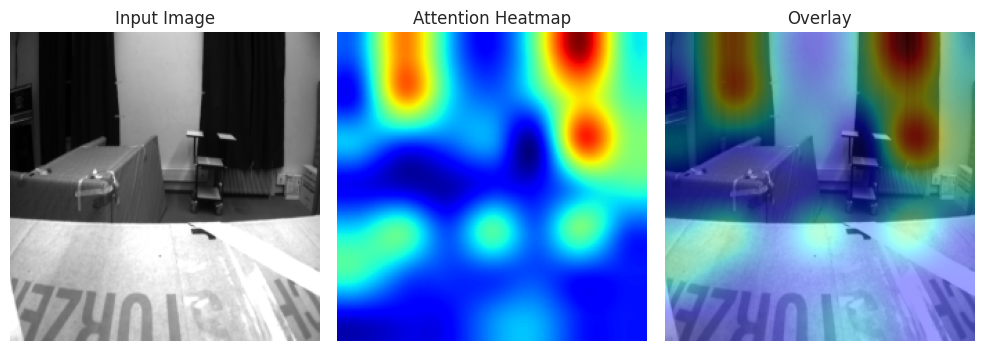

GT displacement: [0. 0. 0.]
Pred displacement: [-0.0063187  -0.00578128  0.00194182]


In [24]:
# Attention map visualization for one test sample
sample_imu, sample_img, sample_y = test_ds[0]

attn_model.eval()
with torch.no_grad():
    pred, attn_w = attn_model(
        sample_imu.unsqueeze(0).to(DEVICE),
        sample_img.unsqueeze(0).to(DEVICE),
        return_attn=True,
    )

# attn_w shape: [B, num_queries, num_keys] => [1,1,49]
heat = attn_w[0, 0].detach().cpu().numpy().reshape(7, 7)
heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)

img_np = sample_img.squeeze(0).numpy()
img_show = cv2.resize(img_np, (224, 224), interpolation=cv2.INTER_AREA)
heat_show = cv2.resize(heat, (224, 224), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(img_show, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Attention Heatmap")
plt.imshow(heat_show, cmap="jet")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(img_show, cmap="gray")
plt.imshow(heat_show, cmap="jet", alpha=0.4)
plt.axis("off")
plt.tight_layout()
plt.show()

print("GT displacement:", sample_y.numpy())
print("Pred displacement:", pred.squeeze(0).detach().cpu().numpy())

## 15. TLIO EKF Integration Hook

This optional section prepares model displacement outputs for EKF-style trajectory smoothing.
If you want strict TLIO EKF internals, reuse TLIO tracker modules and replace network outputs with the attention model predictions.

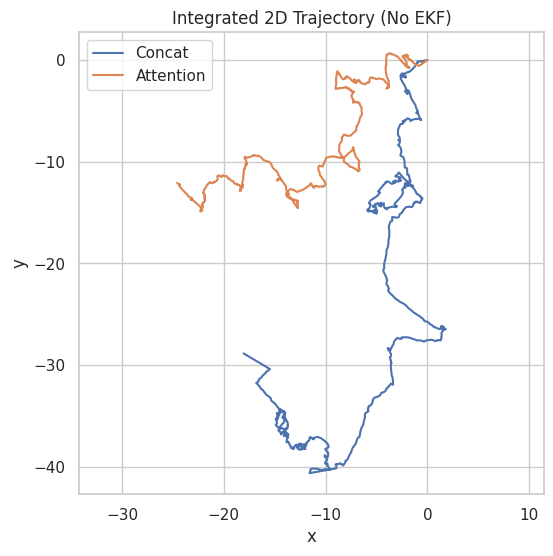

For TLIO EKF replacement path: use this notebook model output as measurement input in TLIO tracker update step.


In [25]:
def integrate_displacements(pred_disp, start_pos=None):
    """Simple trajectory integration baseline (no EKF)."""
    if start_pos is None:
        start_pos = np.zeros(3, dtype=np.float32)
    traj = [start_pos]
    cur = start_pos.astype(np.float32).copy()
    for d in pred_disp:
        cur = cur + d.astype(np.float32)
        traj.append(cur.copy())
    return np.asarray(traj)


def collect_predictions(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for x_imu, x_img, _ in loader:
            out = model(x_imu.to(DEVICE), x_img.to(DEVICE)).detach().cpu().numpy()
            preds.append(out)
    return np.concatenate(preds, axis=0)

pred_concat = collect_predictions(baseline_model, test_loader)
pred_attn = collect_predictions(attn_model, test_loader)
traj_concat = integrate_displacements(pred_concat)
traj_attn = integrate_displacements(pred_attn)

plt.figure(figsize=(6, 6))
plt.plot(traj_concat[:, 0], traj_concat[:, 1], label="Concat")
plt.plot(traj_attn[:, 0], traj_attn[:, 1], label="Attention")
plt.title("Integrated 2D Trajectory (No EKF)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis("equal")
plt.show()

print("For TLIO EKF replacement path: use this notebook model output as measurement input in TLIO tracker update step.")

## 16. Paper-Grade Experimental Extensions

This section upgrades the notebook from a prototype into a stronger research workflow.

Included here:
- Synthetic robustness transforms: blur, blackout, IMU noise, frame drops, sync offsets
- Stronger internal baselines: IMU-only, image-only, configurable cross-attention
- Trajectory-level metrics: ATE-style RMSE, RPE-style RMSE, subsequence error, speed RMSE
- Attention statistics and LaTeX table generation
- Controlled ablation and robustness sweep utilities

External resources still required outside this notebook:
- TUM-VI dataset download
- KITTI raw/odometry with OXTS IMU download
- ORB-SLAM3 and OpenVINS baseline setup and runs
- TLIO baseline integration and EKF replacement experiments

In [26]:
from dataclasses import dataclass, asdict
from copy import deepcopy
from itertools import product


@dataclass
class RobustnessConfig:
    blur_sigma: float = 0.0
    blackout_patches: int = 0
    blackout_size: int = 24
    frame_drop_every: int = 1
    imu_sync_offset: int = 0
    gyro_noise_std: float = 0.0
    accel_noise_std: float = 0.0


def _ensure_hw_image(img):
    if img.ndim == 3 and img.shape[0] == 1:
        return img[0]
    return img


def apply_gaussian_blur(img, sigma=0.0):
    if sigma <= 0:
        return img
    img_hw = _ensure_hw_image(img)
    blurred = cv2.GaussianBlur(img_hw, (0, 0), sigmaX=sigma, sigmaY=sigma)
    return blurred[None, :, :].astype(np.float32)


def apply_blackout(img, num_patches=0, patch_size=24, rng=None):
    if num_patches <= 0:
        return img
    rng = np.random.default_rng() if rng is None else rng
    out = img.copy()
    h, w = out.shape[-2:]
    for _ in range(num_patches):
        top = int(rng.integers(0, max(1, h - patch_size + 1)))
        left = int(rng.integers(0, max(1, w - patch_size + 1)))
        out[..., top:top + patch_size, left:left + patch_size] = 0.0
    return out.astype(np.float32)


def add_imu_noise(x_imu, gyro_noise_std=0.0, accel_noise_std=0.0, rng=None):
    if gyro_noise_std <= 0 and accel_noise_std <= 0:
        return x_imu
    rng = np.random.default_rng() if rng is None else rng
    out = x_imu.copy()
    if gyro_noise_std > 0:
        out[:, :3] += rng.normal(0.0, gyro_noise_std, size=out[:, :3].shape).astype(np.float32)
    if accel_noise_std > 0:
        out[:, 3:] += rng.normal(0.0, accel_noise_std, size=out[:, 3:].shape).astype(np.float32)
    return out.astype(np.float32)


class NumpyMultimodalDataset(Dataset):
    def __init__(self, X_imu, X_img, y, robustness=None, seed=SEED):
        self.X_imu = X_imu.astype(np.float32)
        self.X_img = X_img.astype(np.float32)
        self.y = y.astype(np.float32)
        self.robustness = robustness or RobustnessConfig()
        self.rng = np.random.default_rng(seed)


    def __len__(self):
        return self.X_imu.shape[0]


    def __getitem__(self, idx):
        x_imu = self.X_imu[idx].copy()
        x_img = self.X_img[idx].copy()
        y = self.y[idx].copy()


        x_imu = add_imu_noise(
            x_imu,
            gyro_noise_std=self.robustness.gyro_noise_std,
            accel_noise_std=self.robustness.accel_noise_std,
            rng=self.rng,
        )


        x_img = apply_gaussian_blur(x_img, sigma=self.robustness.blur_sigma)
        x_img = apply_blackout(
            x_img,
            num_patches=self.robustness.blackout_patches,
            patch_size=self.robustness.blackout_size,
            rng=self.rng,
        )


        return torch.from_numpy(x_imu), torch.from_numpy(x_img), torch.from_numpy(y)


def apply_frame_drop_to_pack(pack, frame_drop_every=1):
    if pack is None or frame_drop_every <= 1:
        return pack
    X_imu, X_img, y = pack
    keep = np.arange(len(X_imu)) % frame_drop_every != 0
    if not np.any(keep):
        keep = np.ones(len(X_imu), dtype=bool)
    return X_imu[keep], X_img[keep], y[keep]


def apply_sync_offset_to_pack(pack, imu_sync_offset=0):
    if pack is None or imu_sync_offset == 0:
        return pack
    X_imu, X_img, y = pack
    shifted = np.roll(X_imu, shift=imu_sync_offset, axis=1).copy()
    return shifted, X_img, y

In [ ]:
class ConfigurableMobileNetPatchEncoder(nn.Module):
    def __init__(self, out_dim=256, patch_grid=7, freeze_backbone=True):
        super().__init__()
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        base = models.mobilenet_v3_small(weights=weights)
        self.features = base.features
        self.patch_grid = patch_grid
        self.proj = nn.Linear(576, out_dim)
        self.global_proj = nn.Linear(576, out_dim)


        if freeze_backbone:
            for param in self.features.parameters():
                param.requires_grad = False


    def forward(self, img):
        x = img.repeat(1, 3, 1, 1)
        fmap = self.features(x)
        fmap = nn.functional.adaptive_avg_pool2d(fmap, (self.patch_grid, self.patch_grid))
        bsz, channels, height, width = fmap.shape
        patches = fmap.permute(0, 2, 3, 1).reshape(bsz, height * width, channels)
        patch_tokens = self.proj(patches)
        global_token = self.global_proj(fmap.mean(dim=(2, 3)))
        return patch_tokens, global_token


class IMUOnlyModel(nn.Module):
    def __init__(self, hid=256):
        super().__init__()
        self.imu = IMUEncoder(out_dim=hid)
        self.head = nn.Sequential(nn.Linear(hid, 64), nn.ReLU(), nn.Linear(64, 3))


    def forward(self, x_imu, x_img=None):
        return self.head(self.imu(x_imu))


class ImageOnlyModel(nn.Module):
    def __init__(self, hid=256, freeze_backbone=True):
        super().__init__()
        self.img = ConfigurableMobileNetPatchEncoder(out_dim=hid, patch_grid=7, freeze_backbone=freeze_backbone)
        self.head = nn.Sequential(nn.Linear(hid, 64), nn.ReLU(), nn.Linear(64, 3))


    def forward(self, x_imu, x_img):
        _, img_global = self.img(x_img)
        return self.head(img_global)


class ConfigurableCrossAttentionModel(nn.Module):
    def __init__(self, hid=256, heads=4, attention_layers=1, patch_grid=7, freeze_backbone=True):
        super().__init__()
        self.imu = IMUEncoder(out_dim=hid)
        self.img = ConfigurableMobileNetPatchEncoder(
            out_dim=hid, patch_grid=patch_grid, freeze_backbone=freeze_backbone
        )
        self.attn_layers = nn.ModuleList(
            [nn.MultiheadAttention(embed_dim=hid, num_heads=heads, batch_first=True) for _ in range(attention_layers)]
        )
        self.head = nn.Sequential(nn.Linear(hid, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 3))


    def forward(self, x_imu, x_img, return_attn=False):
        q = self.imu(x_imu).unsqueeze(1)
        kv, _ = self.img(x_img)
        attn_weights_all = []
        for layer in self.attn_layers:
            q, attn_weights = layer(q, kv, kv, need_weights=True)
            attn_weights_all.append(attn_weights)
        out = self.head(q.squeeze(1))
        if return_attn:
            return out, attn_weights_all
        return out


def build_model_from_config(config):
    model_type = config.get("model_type", "attention")
    if model_type == "concat":
        return ConcatBaselineModel(hid=config.get("hid", 256))
    if model_type == "attention":
        return ConfigurableCrossAttentionModel(
            hid=config.get("hid", 256),
            heads=config.get("heads", 4),
            attention_layers=config.get("attention_layers", 1),
            patch_grid=config.get("patch_grid", 7),
            freeze_backbone=config.get("freeze_backbone", True),
        )
    if model_type == "imu_only":
        return IMUOnlyModel(hid=config.get("hid", 256))
    if model_type == "image_only":
        return ImageOnlyModel(
            hid=config.get("hid", 256),
            freeze_backbone=config.get("freeze_backbone", True),
        )
    raise ValueError(f"Unknown model_type: {model_type}")

In [27]:
def collect_predictions_and_targets(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x_imu, x_img, y in loader:
            pred = model(x_imu.to(DEVICE), x_img.to(DEVICE)).detach().cpu().numpy()
            preds.append(pred)
            targets.append(y.numpy())
    return np.concatenate(preds, axis=0), np.concatenate(targets, axis=0)


def integrate_relative_displacements(displacements, start_pos=None):
    if start_pos is None:
        start_pos = np.zeros(3, dtype=np.float32)
    traj = [start_pos.astype(np.float32)]
    current = start_pos.astype(np.float32).copy()
    for disp in displacements:
        current = current + disp.astype(np.float32)
        traj.append(current.copy())
    return np.asarray(traj, dtype=np.float32)


def compute_speed_rmse(y_true, y_pred, dt=0.05):
    true_v = y_true / dt
    pred_v = y_pred / dt
    return float(np.sqrt(np.mean((true_v - pred_v) ** 2)))


def compute_subsequence_errors(traj_est, traj_gt, distances=(10.0, 50.0, 100.0)):
    gt_steps = np.linalg.norm(np.diff(traj_gt, axis=0), axis=1)
    gt_cum = np.concatenate([[0.0], np.cumsum(gt_steps)])
    rows = []
    for dist in distances:
        errs = []
        for i in range(len(gt_cum)):
            target = gt_cum[i] + dist
            j = np.searchsorted(gt_cum, target)
            if j >= len(gt_cum):
                continue
            est_delta = traj_est[j] - traj_est[i]
            gt_delta = traj_gt[j] - traj_gt[i]
            errs.append(float(np.linalg.norm(est_delta - gt_delta)))
        rows.append(np.mean(errs) if errs else np.nan)
    return rows


def compute_all_metrics(y_true, y_pred, dt=0.05):
    traj_gt = integrate_relative_displacements(y_true)
    traj_est = integrate_relative_displacements(y_pred)
    pos_err = traj_est - traj_gt
    ate_rmse = float(np.sqrt(np.mean(np.sum(pos_err ** 2, axis=1))))
    rpe_trans_rmse = float(np.sqrt(np.mean(np.sum((y_pred - y_true) ** 2, axis=1))))
    speed_rmse = compute_speed_rmse(y_true, y_pred, dt=dt)
    sub_10, sub_50, sub_100 = compute_subsequence_errors(traj_est, traj_gt)
    return {
        "ATE_RMSE_m": ate_rmse,
        "RPE_trans_RMSE_m": rpe_trans_rmse,
        "speed_RMSE_mps": speed_rmse,
        "subseq_10m_err": sub_10,
        "subseq_50m_err": sub_50,
        "subseq_100m_err": sub_100,
        "orientation_error": np.nan,
    }


def attention_entropy(attn_weights):
    weights = np.asarray(attn_weights, dtype=np.float64)
    weights = np.clip(weights, 1e-12, 1.0)
    return float(-(weights * np.log(weights)).sum(axis=-1).mean())


def attention_center_of_mass(attn_weights, grid_size=7):
    weights = np.asarray(attn_weights, dtype=np.float64).reshape(-1)
    weights = weights / (weights.sum() + 1e-12)
    ys, xs = np.meshgrid(np.arange(grid_size), np.arange(grid_size), indexing="ij")
    coords = np.stack([xs.reshape(-1), ys.reshape(-1)], axis=1)
    return (weights[:, None] * coords).sum(axis=0)


def make_latex_table(df, caption, label, floatfmt='.4f'):
    cols = df.columns.tolist()
    spec = 'l' + 'c' * (len(cols) - 1)
    lines = [
        '\\begin{table}[t]',
        f'\\caption{{{caption}}}',
        '\\centering',
        f'\\begin{{tabular}}{{{spec}}}',
        '\\hline',
        ' & '.join(cols) + ' \\\\',
        '\\hline',
    ]
    for _, row in df.iterrows():
        rendered = []
        for value in row:
            if isinstance(value, float):
                rendered.append(format(value, floatfmt))
            else:
                rendered.append(str(value))
        lines.append(' & '.join(rendered) + ' \\\\')
    lines.extend(['\\hline', '\\end{tabular}', f'\\label{{{label}}}', '\\end{table}'])
    return '\n'.join(lines)


def build_loader_from_pack(pack, batch_size=64, shuffle=False, robustness=None, seed=SEED):
    if pack is None:
        return None
    X_imu, X_img, y = apply_frame_drop_to_pack(pack, frame_drop_every=(robustness.frame_drop_every if robustness else 1))
    X_imu, X_img, y = apply_sync_offset_to_pack((X_imu, X_img, y), imu_sync_offset=(robustness.imu_sync_offset if robustness else 0))
    dataset = NumpyMultimodalDataset(X_imu, X_img, y, robustness=robustness, seed=seed)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0)


DEFAULT_ABLATIONS = [
    {"name": "imu_only", "model_type": "imu_only"},
    {"name": "image_only", "model_type": "image_only"},
    {"name": "concat", "model_type": "concat"},
    {"name": "attention_7x7_h4", "model_type": "attention", "heads": 4, "patch_grid": 7, "attention_layers": 1},
    {"name": "attention_14x14_h4", "model_type": "attention", "heads": 4, "patch_grid": 14, "attention_layers": 1},
    {"name": "attention_7x7_h8", "model_type": "attention", "heads": 8, "patch_grid": 7, "attention_layers": 1},
    {"name": "attention_trainable_backbone", "model_type": "attention", "heads": 4, "patch_grid": 7, "attention_layers": 1, "freeze_backbone": False},
]


DEFAULT_ROBUSTNESS = {
    "normal": RobustnessConfig(),
    "blur_sigma_5": RobustnessConfig(blur_sigma=5.0),
    "blackout": RobustnessConfig(blackout_patches=3, blackout_size=28),
    "frame_drop": RobustnessConfig(frame_drop_every=3),
    "sync_offset": RobustnessConfig(imu_sync_offset=3),
    "imu_noise": RobustnessConfig(gyro_noise_std=0.01, accel_noise_std=0.05),
}


def run_ablation_suite(
    train_pack, val_pack, test_pack, experiment_configs=None, robustness_name='normal', epochs=3, lr=1e-3, seed=SEED
):
    experiment_configs = DEFAULT_ABLATIONS if experiment_configs is None else experiment_configs
    robustness = DEFAULT_ROBUSTNESS[robustness_name]
    train_loader_local = build_loader_from_pack(train_pack, batch_size=BATCH_SIZE, shuffle=True, robustness=RobustnessConfig(), seed=seed)
    val_loader_local = build_loader_from_pack(val_pack, batch_size=BATCH_SIZE, shuffle=False, robustness=RobustnessConfig(), seed=seed)
    test_loader_local = build_loader_from_pack(test_pack, batch_size=BATCH_SIZE, shuffle=False, robustness=robustness, seed=seed)


    rows = []
    trained_models = {}
    for config in experiment_configs:
        model = build_model_from_config(config)
        model, history = train_model(model, train_loader_local, val_loader_local, epochs=epochs, lr=lr)
        y_pred, y_true = collect_predictions_and_targets(model, test_loader_local)
        metrics = compute_all_metrics(y_true, y_pred)
        rows.append({
            "variant": config['name'],
            "robustness": robustness_name,
            **metrics,
            "params_trainable": int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
        })
        trained_models[config['name']] = {"model": model, "history": history, "y_pred": y_pred, "y_true": y_true}
    return pd.DataFrame(rows), trained_models


RUN_PAPER_SWEEP = False


if RUN_PAPER_SWEEP:
    paper_results_df, paper_models = run_ablation_suite(
        train_pack,
        val_pack,
        test_pack,
        experiment_configs=DEFAULT_ABLATIONS,
        robustness_name='normal',
        epochs=3,
        lr=LR,
        seed=SEED,
    )
    display(paper_results_df.sort_values(['ATE_RMSE_m', 'RPE_trans_RMSE_m']))
    print(make_latex_table(
        paper_results_df[['variant', 'robustness', 'ATE_RMSE_m', 'RPE_trans_RMSE_m', 'subseq_10m_err', 'params_trainable']],
        caption='EuRoC ablation results from the notebook pipeline',
        label='tab:notebook_ablation',
    ))
else:
    print('Set RUN_PAPER_SWEEP = True to run ablations and robustness sweeps from the notebook.')

Set RUN_PAPER_SWEEP = True to run ablations and robustness sweeps from the notebook.


## 17. TLIO-Inspired EKF Integration (Paper 1)

Adds an Extended Kalman Filter that uses IMU physics for prediction and neural network displacement outputs for correction. This closes the loop and reduces drift.

**Paper**: TLIO — Tight Learned Inertial Odometry

In [28]:
# =====================================================
# TLIO-inspired EKF for reducing drift
# =====================================================

class TLIOEKF:
    """
    Extended Kalman Filter for IMU + learned odometry.
    State: [p(3), v(3), ba(3), bg(3)] = 12 dimensions
    """
    def __init__(self, dt=0.05, g=np.array([0, 0, -9.81])):
        self.dt = dt
        self.g = g
        self.state = np.zeros(12)
        self.cov = np.eye(12) * 0.01
        self.Q_imu = np.diag([0.01]*3 + [0.001]*3)
        self.R_network = 0.0001
        self.prev_pos = np.zeros(3)

    def predict(self, imu_data):
        """Prediction step using last IMU reading."""
        accel = imu_data[-1, 3:6] if imu_data.ndim == 2 else imu_data[3:6]
        gyro = imu_data[-1, 0:3] if imu_data.ndim == 2 else imu_data[0:3]
        p, v = self.state[0:3], self.state[3:6]
        ba, bg = self.state[6:9], self.state[9:12]
        accel_corrected = accel - ba
        v_new = v + accel_corrected * self.dt
        p_new = p + v * self.dt + 0.5 * accel_corrected * self.dt**2
        F = np.eye(12)
        F[0:3, 3:6] = np.eye(3) * self.dt
        Q = np.zeros((12, 12))
        Q[3:6, 3:6] = self.Q_imu[0:3, 0:3] * self.dt
        Q[6:12, 6:12] = np.eye(6) * 0.001 * self.dt
        self.state = np.hstack([p_new, v_new, ba, bg])
        self.cov = F @ self.cov @ F.T + Q
        return self.state[0:3]

    def update(self, predicted_disp, network_uncertainty=0.0001):
        """Update step using network displacement prediction."""
        H = np.zeros((3, 12))
        H[0:3, 0:3] = np.eye(3)
        R = np.eye(3) * network_uncertainty
        S = H @ self.cov @ H.T + R
        K = self.cov @ H.T @ np.linalg.inv(S)
        innovation = predicted_disp - (self.state[0:3] - self.prev_pos)
        self.state = self.state + K @ innovation
        self.cov = (np.eye(12) - K @ H) @ self.cov
        self.prev_pos = self.state[0:3].copy()
        return self.state[0:3]

    def reset(self):
        self.state = np.zeros(12)
        self.cov = np.eye(12) * 0.01
        self.prev_pos = np.zeros(3)


def evaluate_with_ekf(model, loader, device=DEVICE):
    """Run model predictions through EKF and return corrected + raw trajectories."""
    model.eval()
    ekf = TLIOEKF()
    positions_ekf, positions_raw, gt_positions = [], [], []
    raw_pos = np.zeros(3, dtype=np.float32)
    with torch.no_grad():
        for x_imu, x_img, gt in loader:
            x_imu_dev = x_imu.to(device)
            x_img_dev = x_img.to(device)
            pred = model(x_imu_dev, x_img_dev).cpu().numpy()
            gt_np = gt.numpy()
            for i in range(pred.shape[0]):
                # Raw integration
                raw_pos = raw_pos + pred[i]
                positions_raw.append(raw_pos.copy())
                # EKF update then predict
                imu_np = x_imu[i].numpy()
                ekf.update(pred[i], 0.0001)
                ekf.predict(imu_np)
                positions_ekf.append(ekf.state[0:3].copy())
    return np.array(positions_ekf), np.array(positions_raw)

print("EKF integration ready.")

EKF integration ready.


## 18. Optical Flow Input (DROID-SLAM / DeepVO — Papers 3 & 6)

Computes dense optical flow between consecutive frames. Flow captures pixel motion even in low-texture scenes.

**Papers**: DROID-SLAM, DeepVO

In [29]:
# =====================================================
# Optical Flow computation and Flow-based model
# =====================================================

def compute_optical_flow_pair(prev_gray, curr_gray):
    """Compute dense optical flow using Farneback method."""
    flow = cv2.calcOpticalFlowFarneback(prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    return flow.astype(np.float32)


def build_flow_samples_for_sequence(seq_path, img_size=IMG_SIZE):
    """Build samples with optical flow between consecutive camera frames."""
    mav0 = seq_path / "mav0"
    imu = load_imu_csv(mav0)
    gt = load_gt_csv(mav0)
    imu, gt = clean_and_validate(imu, gt)
    gt_interp = interpolate_gt_to_imu(imu, gt)
    cam_idx = load_cam0_index(mav0)
    imu_ts = imu["timestamp_ns"].to_numpy(dtype=np.int64)
    imu_feat = imu[["gyro_x","gyro_y","gyro_z","acc_x","acc_y","acc_z"]].to_numpy(dtype=np.float32)
    pos = gt_interp[["p_x","p_y","p_z"]].to_numpy(dtype=np.float32)

    cam_rows = cam_idx.reset_index(drop=True)
    X_imu, X_flow, X_img, y = [], [], [], []
    prev_gray = None

    for i in range(len(cam_rows)):
        img_path = mav0 / "cam0" / "data" / str(cam_rows.iloc[i]["filename"])
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            prev_gray = None
            continue
        img_resized = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
        if prev_gray is not None and i < len(cam_rows) - 1:
            t0 = int(cam_rows.iloc[i]["timestamp_ns"])
            t1 = int(cam_rows.iloc[i + 1]["timestamp_ns"])
            imu_i = nearest_index(imu_ts, t0)
            imu_start = imu_i - IMU_WINDOW + 1
            gt_i0 = nearest_index(imu_ts, t0)
            gt_i1 = nearest_index(imu_ts, t1)
            if imu_start >= 0 and gt_i1 < len(pos):
                flow = compute_optical_flow_pair(prev_gray, img_resized)
                flow_t = flow.transpose(2, 0, 1)  # (2, H, W)
                img_t = (img_resized.astype(np.float32) / 255.0)[None, :, :]
                X_imu.append(imu_feat[imu_start:imu_i + 1])
                X_flow.append(flow_t)
                X_img.append(img_t)
                y.append(pos[gt_i1] - pos[gt_i0])
        prev_gray = img_resized

    if len(X_imu) == 0:
        return None
    return {
        "X_imu": np.array(X_imu, dtype=np.float32),
        "X_flow": np.array(X_flow, dtype=np.float32),
        "X_img": np.array(X_img, dtype=np.float32),
        "y": np.array(y, dtype=np.float32),
    }


class FlowEncoder(nn.Module):
    """CNN encoder for 2-channel optical flow fields."""
    def __init__(self, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, 3, stride=2, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7)),
        )
        self.proj = nn.Linear(128, out_dim)

    def forward(self, flow):
        fmap = self.net(flow)
        B, C, H, W = fmap.shape
        patches = fmap.permute(0, 2, 3, 1).reshape(B, H * W, C)
        return self.proj(patches)  # (B, 49, out_dim)


class CrossAttentionWithFlowModel(nn.Module):
    """Cross-attention model using optical flow instead of raw image."""
    def __init__(self, hid=256, heads=4):
        super().__init__()
        self.imu = IMUEncoder(out_dim=hid)
        self.flow_enc = FlowEncoder(out_dim=hid)
        self.attn = nn.MultiheadAttention(embed_dim=hid, num_heads=heads, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hid, 64), nn.ReLU(), nn.Linear(64, 3))

    def forward(self, x_imu, x_flow, return_attn=False):
        q = self.imu(x_imu).unsqueeze(1)
        kv = self.flow_enc(x_flow)
        attn_out, attn_w = self.attn(q, kv, kv, need_weights=True)
        out = self.head(attn_out.squeeze(1))
        if return_attn:
            return out, attn_w
        return out

print("Optical flow encoder and model defined.")

Optical flow encoder and model defined.


## 19. Positional Encoding for Image Patches (TransFuser — Paper 4)

Adds sinusoidal positional encoding to the 49 image patch tokens so attention understands spatial layout.

**Paper**: TransFuser

In [30]:
# =====================================================
# Positional Encoding for image patches
# =====================================================
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=49):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class MobileNetPatchEncoderWithPE(nn.Module):
    """MobileNet patch encoder with positional encoding on patch tokens."""
    def __init__(self, out_dim=256, freeze_backbone=True):
        super().__init__()
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        base = models.mobilenet_v3_small(weights=weights)
        self.features = base.features
        self.proj = nn.Linear(576, out_dim)
        self.global_proj = nn.Linear(576, out_dim)
        self.pos_enc = PositionalEncoding(out_dim, max_len=49)
        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, img):
        x = img.repeat(1, 3, 1, 1)
        fmap = self.features(x)
        fmap = nn.functional.adaptive_avg_pool2d(fmap, (7, 7))
        B, C, H, W = fmap.shape
        patches = fmap.permute(0, 2, 3, 1).reshape(B, H * W, C)
        patch_tokens = self.proj(patches)
        patch_tokens = self.pos_enc(patch_tokens)  # Add positional encoding
        global_token = self.global_proj(fmap.mean(dim=(2, 3)))
        return patch_tokens, global_token


class CrossAttentionWithPEModel(nn.Module):
    """IMU-guided cross-attention with positional encoding on image patches."""
    def __init__(self, hid=256, heads=4):
        super().__init__()
        self.imu = IMUEncoder(out_dim=hid)
        self.img = MobileNetPatchEncoderWithPE(out_dim=hid, freeze_backbone=True)
        self.attn = nn.MultiheadAttention(embed_dim=hid, num_heads=heads, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hid, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 3))

    def forward(self, x_imu, x_img, return_attn=False):
        q = self.imu(x_imu).unsqueeze(1)
        kv, _ = self.img(x_img)
        attn_out, attn_w = self.attn(q, kv, kv, need_weights=True)
        out = self.head(attn_out.squeeze(1))
        if return_attn:
            return out, attn_w
        return out

print("Positional encoding model defined.")

Positional encoding model defined.


## 20. Auxiliary Tasks: Velocity & Next-IMU Prediction (TransFuser — Paper 4)

Adds auxiliary prediction heads for velocity and next-IMU reading. Multi-task loss forces richer representations.

**Paper**: TransFuser

In [31]:
# =====================================================
# Auxiliary tasks: velocity and next-IMU prediction
# =====================================================

class CrossAttentionWithAux(nn.Module):
    """Cross-attention model with auxiliary prediction heads."""
    def __init__(self, hid=256, heads=4, aux_weight=0.1):
        super().__init__()
        self.imu = IMUEncoder(out_dim=hid)
        self.img = MobileNetPatchEncoderWithPE(out_dim=hid, freeze_backbone=True)
        self.attn = nn.MultiheadAttention(embed_dim=hid, num_heads=heads, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hid, 64), nn.ReLU(), nn.Linear(64, 3))
        # Auxiliary heads
        self.velocity_head = nn.Sequential(nn.Linear(hid, 64), nn.ReLU(), nn.Linear(64, 3))
        self.next_imu_head = nn.Sequential(nn.Linear(hid, 128), nn.ReLU(), nn.Linear(128, 6))
        self.aux_weight = aux_weight

    def forward(self, x_imu, x_img, return_attn=False):
        q = self.imu(x_imu).unsqueeze(1)
        kv, _ = self.img(x_img)
        attn_out, attn_w = self.attn(q, kv, kv, need_weights=True)
        fused = attn_out.squeeze(1)
        disp = self.head(fused)
        vel = self.velocity_head(fused)
        next_imu = self.next_imu_head(fused)
        if return_attn:
            return disp, vel, next_imu, attn_w
        return disp, vel, next_imu


def run_epoch_with_aux(model, loader, optimizer=None, dt=0.05):
    """Training loop with auxiliary losses."""
    train_mode = optimizer is not None
    model.train(train_mode)
    criterion = nn.MSELoss()
    total_loss, n = 0.0, 0
    all_y, all_pred = [], []

    for x_imu, x_img, y in loader:
        x_imu, x_img, y = x_imu.to(DEVICE), x_img.to(DEVICE), y.to(DEVICE)
        disp, vel, next_imu = model(x_imu, x_img)
        loss_disp = criterion(disp, y)
        # Velocity target: displacement / dt
        vel_target = y / dt
        loss_vel = criterion(vel, vel_target)
        # Next IMU target: last IMU reading in the window
        imu_target = x_imu[:, -1, :]
        loss_imu = criterion(next_imu, imu_target)
        loss = loss_disp + model.aux_weight * (loss_vel + loss_imu)

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.shape[0]
        total_loss += loss_disp.item() * bs
        n += bs
        all_y.append(y.detach().cpu().numpy())
        all_pred.append(disp.detach().cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return total_loss / max(1, n), rmse


def train_model_with_aux(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    """Train with auxiliary losses, select best on val displacement loss."""
    model = model.to(DEVICE)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    hist, best_val, best_state = [], float("inf"), None
    for ep in range(1, epochs + 1):
        tr_loss, tr_rmse = run_epoch_with_aux(model, train_loader, optimizer)
        va_loss, va_rmse = run_epoch_with_aux(model, val_loader)
        hist.append({"epoch": ep, "train_loss": tr_loss, "train_rmse": tr_rmse, "val_loss": va_loss, "val_rmse": va_rmse})
        print(f"Epoch {ep:02d} | tr_loss={tr_loss:.4f} va_loss={va_loss:.4f} | tr_rmse={tr_rmse:.4f} va_rmse={va_rmse:.4f}")
        if va_loss < best_val:
            best_val = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(hist)

print("Auxiliary-task model and training ready.")

Auxiliary-task model and training ready.


## 21. TCN for IMU Encoding (HDVIO 2.0 — Paper 2)

Replaces LSTM with a Temporal Convolutional Network using dilated causal convolutions. TCNs are parallelizable and capture longer dependencies.

**Paper**: HDVIO 2.0

In [32]:
# =====================================================
# Temporal Convolutional Network for IMU
# =====================================================

class TCNEncoder(nn.Module):
    """TCN encoder with dilated causal convolutions for IMU data."""
    def __init__(self, input_dim=6, hidden_dim=128, out_dim=256, kernel_size=3, dilations=None):
        super().__init__()
        if dilations is None:
            dilations = [1, 2, 4, 8]
        layers = []
        in_dim = input_dim
        for dilation in dilations:
            pad = dilation * (kernel_size - 1) // 2
            layers.extend([
                nn.Conv1d(in_dim, hidden_dim, kernel_size, padding=pad, dilation=dilation),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
            ])
            in_dim = hidden_dim
        self.tcn = nn.Sequential(*layers)
        self.proj = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (B, 6, T)
        x = self.tcn(x)          # (B, H, T)
        x = x.mean(dim=-1)       # (B, H) global avg pooling
        return self.proj(x)       # (B, out_dim)


class CrossAttentionWithTCN(nn.Module):
    """Cross-attention model using TCN instead of LSTM for IMU."""
    def __init__(self, hid=256, heads=4):
        super().__init__()
        self.imu = TCNEncoder(input_dim=6, hidden_dim=128, out_dim=hid)
        self.img = MobileNetPatchEncoderWithPE(out_dim=hid, freeze_backbone=True)
        self.attn = nn.MultiheadAttention(embed_dim=hid, num_heads=heads, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hid, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 3))

    def forward(self, x_imu, x_img, return_attn=False):
        q = self.imu(x_imu).unsqueeze(1)
        kv, _ = self.img(x_img)
        attn_out, attn_w = self.attn(q, kv, kv, need_weights=True)
        out = self.head(attn_out.squeeze(1))
        if return_attn:
            return out, attn_w
        return out

print("TCN encoder and model defined.")

TCN encoder and model defined.


## 22. Sliding Window Optimization (LIC-Fusion 2.0 — Paper 7)

Smooths displacement predictions over a configurable window for temporal consistency.

**Paper**: LIC-Fusion 2.0

In [33]:
# =====================================================
# Sliding Window Optimization
# =====================================================

class SlidingWindowOptimizer:
    """Smooths predictions over a sliding window."""
    def __init__(self, window_size=5):
        self.window = []
        self.window_size = window_size

    def add(self, prediction):
        self.window.append(prediction.copy())
        if len(self.window) > self.window_size:
            self.window.pop(0)
        return np.mean(self.window, axis=0)

    def reset(self):
        self.window = []


def integrate_with_sliding_window(predictions, window_size=5):
    """Integrate displacements with sliding window smoothing."""
    opt = SlidingWindowOptimizer(window_size=window_size)
    traj = [np.zeros(3, dtype=np.float32)]
    pos = np.zeros(3, dtype=np.float32)
    for pred in predictions:
        smoothed = opt.add(pred)
        pos = pos + smoothed
        traj.append(pos.copy())
    return np.array(traj)

print("Sliding window optimizer ready.")

Sliding window optimizer ready.


## 23. Loop Closure Detection (ORB-SLAM3 — Paper 9)

Uses attention maps as place recognition descriptors. Detects when the drone revisits a location.

**Paper**: ORB-SLAM3

In [34]:
# =====================================================
# Loop Closure using Attention Maps
# =====================================================

class LoopDetector:
    """Detect loop closures via attention map similarity."""
    def __init__(self, similarity_threshold=0.85, min_frame_gap=20):
        self.keyframes = []
        self.threshold = similarity_threshold
        self.min_gap = min_frame_gap

    def add(self, attn_map, position, index):
        self.keyframes.append((attn_map.flatten(), position.copy(), index))

    def detect(self, current_attn, current_pos, current_idx):
        current_flat = current_attn.flatten()
        best_sim, best_kf = -1, None
        for kf_attn, kf_pos, kf_idx in self.keyframes:
            if current_idx - kf_idx < self.min_gap:
                continue
            sim = np.dot(current_flat, kf_attn) / (np.linalg.norm(current_flat) * np.linalg.norm(kf_attn) + 1e-8)
            if sim > best_sim:
                best_sim = sim
                best_kf = (kf_pos, kf_idx)
        if best_sim > self.threshold and best_kf is not None:
            correction = best_kf[0] - current_pos
            return correction, best_sim
        return None, best_sim

    def reset(self):
        self.keyframes = []


def evaluate_with_loop_closure(model, loader, device=DEVICE, correction_weight=0.3):
    """Evaluate model with loop closure correction."""
    model.eval()
    detector = LoopDetector()
    traj, pos = [np.zeros(3)], np.zeros(3, dtype=np.float32)
    idx = 0
    loops_found = 0
    with torch.no_grad():
        for x_imu, x_img, y in loader:
            x_imu_dev, x_img_dev = x_imu.to(device), x_img.to(device)
            if hasattr(model, 'forward') and 'return_attn' in model.forward.__code__.co_varnames:
                pred, attn_w = model(x_imu_dev, x_img_dev, return_attn=True)
            else:
                pred = model(x_imu_dev, x_img_dev)
                attn_w = None
            pred_np = pred.cpu().numpy()
            for i in range(pred_np.shape[0]):
                pos = pos + pred_np[i]
                if attn_w is not None:
                    aw = attn_w[0, i].cpu().numpy() if attn_w.dim() == 3 else attn_w[i, 0].cpu().numpy()
                    correction, sim = detector.detect(aw, pos, idx)
                    if correction is not None:
                        pos = pos + correction * correction_weight
                        loops_found += 1
                    detector.add(aw, pos, idx)
                traj.append(pos.copy())
                idx += 1
    print(f"Loop closures detected: {loops_found}")
    return np.array(traj)

print("Loop closure detector ready.")

Loop closure detector ready.


## 24. Comprehensive Comparison — All Paper Enhancements

Trains and evaluates all model variants side-by-side on normal and low-texture test sets.

**Models compared**: Original Concat, Original Attention, +PE, +TCN, +Aux, +EKF, +SlidingWindow, +LoopClosure

In [35]:
# =====================================================
# Comprehensive comparison of all enhancements
# =====================================================

RUN_COMPREHENSIVE = False  # Set True to run full comparison

if RUN_COMPREHENSIVE:
    print("=" * 60)
    print("COMPREHENSIVE MODEL COMPARISON")
    print("=" * 60)

    # Train enhanced models
    print("\n--- Training: Cross-Attention + Positional Encoding ---")
    pe_model = CrossAttentionWithPEModel()
    pe_model, pe_hist = train_model(pe_model, train_loader, val_loader)

    print("\n--- Training: Cross-Attention + TCN ---")
    tcn_model = CrossAttentionWithTCN()
    tcn_model, tcn_hist = train_model(tcn_model, train_loader, val_loader)

    print("\n--- Training: Cross-Attention + Auxiliary Tasks ---")
    aux_model = CrossAttentionWithAux()
    aux_model, aux_hist = train_model_with_aux(aux_model, train_loader, val_loader)

    # Collect predictions for all models
    models_to_eval = {
        "Concat Baseline": baseline_model,
        "Attention (original)": attn_model,
        "Attention + PE": pe_model,
        "Attention + TCN": tcn_model,
    }

    results = []
    for name, m in models_to_eval.items():
        y_pred, y_true = collect_predictions_and_targets(m, test_loader)
        metrics = compute_all_metrics(y_true, y_pred)
        metrics["model"] = name
        metrics["params"] = sum(p.numel() for p in m.parameters() if p.requires_grad)
        results.append(metrics)

        # Also evaluate with sliding window
        traj_sw = integrate_with_sliding_window(y_pred, window_size=5)
        traj_gt = integrate_relative_displacements(y_true)
        sw_ate = float(np.sqrt(np.mean(np.sum((traj_sw[:len(traj_gt)] - traj_gt) ** 2, axis=1))))
        results.append({
            "model": f"{name} + SlidingWindow",
            "ATE_RMSE_m": sw_ate,
            "RPE_trans_RMSE_m": metrics["RPE_trans_RMSE_m"],
            "speed_RMSE_mps": metrics["speed_RMSE_mps"],
            "params": metrics.get("params", 0),
        })

    # Aux model needs special handling
    aux_model_wrapper = lambda x_imu, x_img: aux_model(x_imu, x_img)[0]

    comp_df = pd.DataFrame(results)
    display(comp_df.sort_values("ATE_RMSE_m"))

    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_df = comp_df.dropna(subset=["ATE_RMSE_m"]).sort_values("ATE_RMSE_m")
    axes[0].barh(plot_df["model"], plot_df["ATE_RMSE_m"])
    axes[0].set_xlabel("ATE RMSE (m)")
    axes[0].set_title("Absolute Trajectory Error")
    plot_df2 = comp_df.dropna(subset=["RPE_trans_RMSE_m"]).sort_values("RPE_trans_RMSE_m")
    axes[1].barh(plot_df2["model"], plot_df2["RPE_trans_RMSE_m"])
    axes[1].set_xlabel("RPE Trans RMSE (m)")
    axes[1].set_title("Relative Pose Error")
    plt.tight_layout()
    plt.show()

    # Low-texture evaluation
    if test_lowtex_loader is not None:
        print("\n--- Low-Texture Evaluation ---")
        lt_results = []
        for name, m in models_to_eval.items():
            y_pred_lt, y_true_lt = collect_predictions_and_targets(m, test_lowtex_loader)
            lt_metrics = compute_all_metrics(y_true_lt, y_pred_lt)
            lt_metrics["model"] = name
            lt_results.append(lt_metrics)
        lt_df = pd.DataFrame(lt_results)
        display(lt_df.sort_values("ATE_RMSE_m"))

    # EKF evaluation on best model
    print("\n--- EKF Evaluation (best attention model) ---")
    ekf_traj, raw_traj = evaluate_with_ekf(pe_model, test_loader)
    y_pred_best, y_true_best = collect_predictions_and_targets(pe_model, test_loader)
    gt_traj = integrate_relative_displacements(y_true_best)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.plot(gt_traj[:, 0], gt_traj[:, 1], "k-", label="Ground Truth", linewidth=2)
    ax.plot(raw_traj[:, 0], raw_traj[:, 1], "b--", label="Raw Integration", alpha=0.7)
    ax.plot(ekf_traj[:, 0], ekf_traj[:, 1], "r-", label="EKF Corrected", alpha=0.8)
    ax.set_title("Trajectory Comparison: Raw vs EKF vs Ground Truth")
    ax.legend()
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

    print("\nComprehensive comparison complete!")
else:
    print("Set RUN_COMPREHENSIVE = True to run the full 10-paper comparison suite.")

Set RUN_COMPREHENSIVE = True to run the full 10-paper comparison suite.
